# Imports and Reading data

In [109]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [110]:
df = pd.read_csv('safe-to-operate.csv')

# Data understanding

In [111]:
df.shape

# 10000 rows and 5 columns as expected

(10000, 5)

In [112]:
df.head(5)

# I realize I wrongly named the forth column "y". It should have been "converged", but it doesn't really matter.

,optimizer_gain,dither_amplitude,dither_frequency,y,convergence_time
0,0.000614,0.087253,0.216675,1,47.72
1,0.006499,0.070116,0.133079,0,NaN
2,0.000175,0.407321,0.033729,1,87.96
3,0.003311,0.319953,0.130948,1,78.26
4,0.000011,0.203432,0.481182,0,NaN


In [113]:
df.dtypes

optimizer_gain      float64
dither_amplitude    float64
dither_frequency    float64
y                     int64
convergence_time    float64
dtype: object

# Data preparation

In [114]:
df.isna().sum()

# only the convergence_time has duplicated values(7464) so we do not need to drop any rows

optimizer_gain         0
dither_amplitude       0
dither_frequency       0
y                      0
convergence_time    7464
dtype: int64

# Feature understanding

Text(0, 0.5, 'Counts')

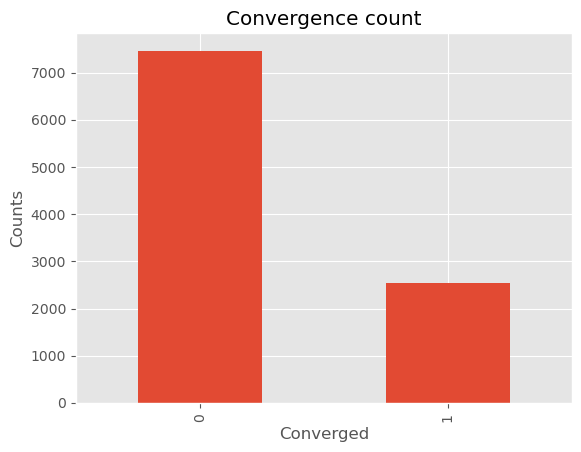

In [115]:
cv = df['y'].value_counts().head(10).plot(kind = 'bar', title = 'Convergence count')

cv.set_xlabel('Converged')
cv.set_ylabel('Counts')

# Only about one-forth of the values converged

Text(0, 0.5, 'Frequency')

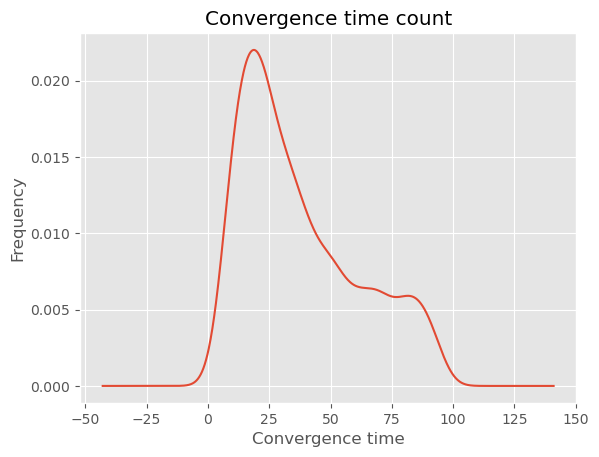

In [116]:
ct = df['convergence_time'].plot(kind = 'kde',
                title = 'Convergence time count')
ct.set_xlabel('Convergence time')
ct.set_ylabel('Frequency')

# The peak of the graph is at time < 25 (probably around 20), which is not really bad considering the goal is to have convergence_time < 10

In [117]:
sum(df['convergence_time'] < 10)

# There are 178 out of 10000 combinations that has the convergence_time < 10, which I hope is enough to work with

178

# Feature relationships

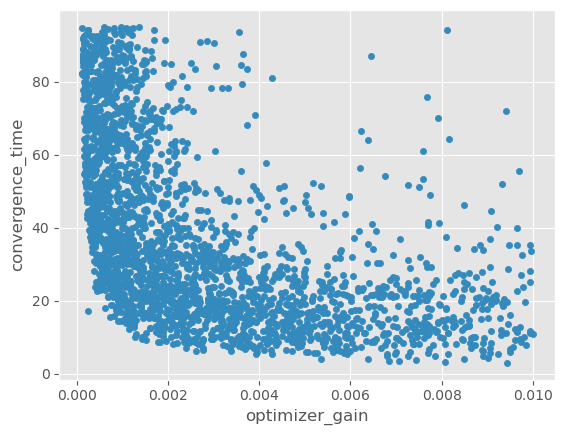

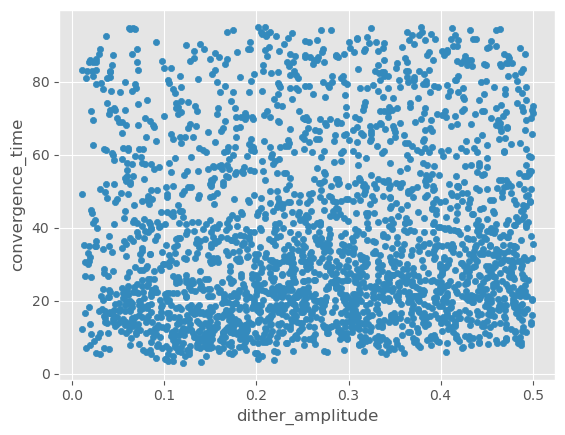

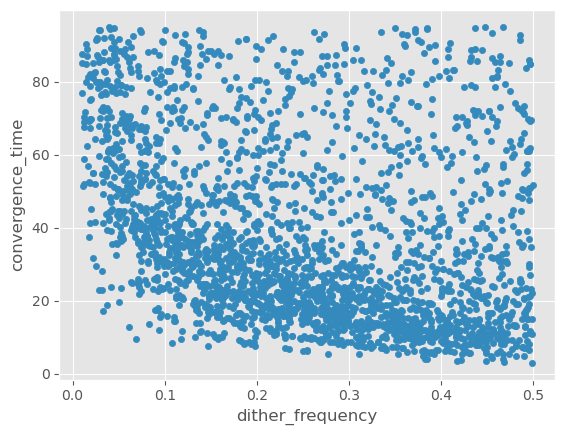

In [118]:
for i in range (df.shape[1] - 2):
    df.plot(kind = 'scatter',
            x = i,
            y = 'convergence_time')
    plt.show()

# As I already achived 40 seconds in my code, we should only look at time <= 40 as the data is quite overwhelming 

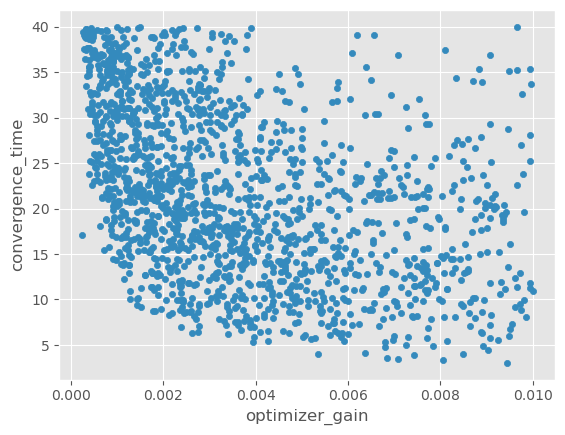

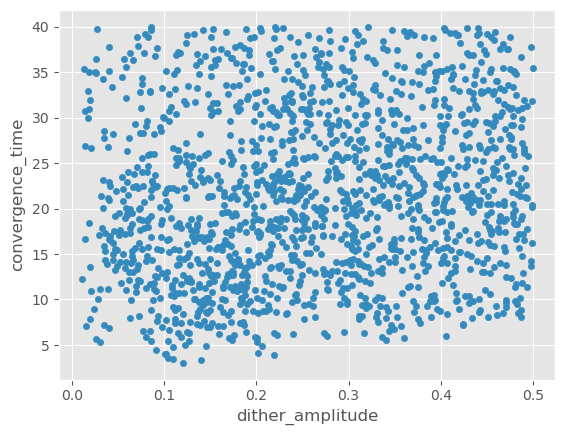

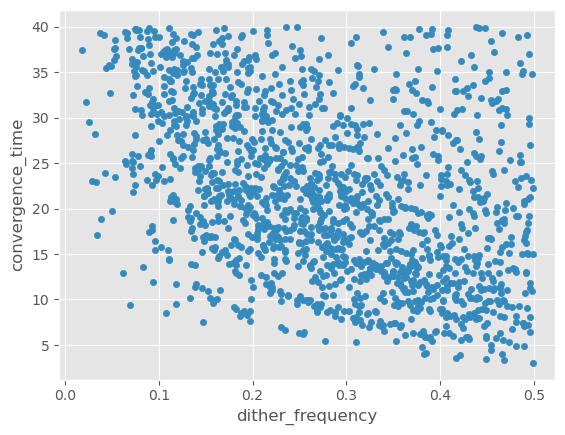

In [119]:
dfcut = df[df['convergence_time'] < 40]
for i in range (dfcut.shape[1] - 2):
    dfcut.plot(kind = 'scatter',
            x = i,
            y = 'convergence_time')
    plt.show()
# It seems like optimizer gain and dither frequency have inverse relationships while dither amplitude has a direct relationship (which is not very clear) with convergence time

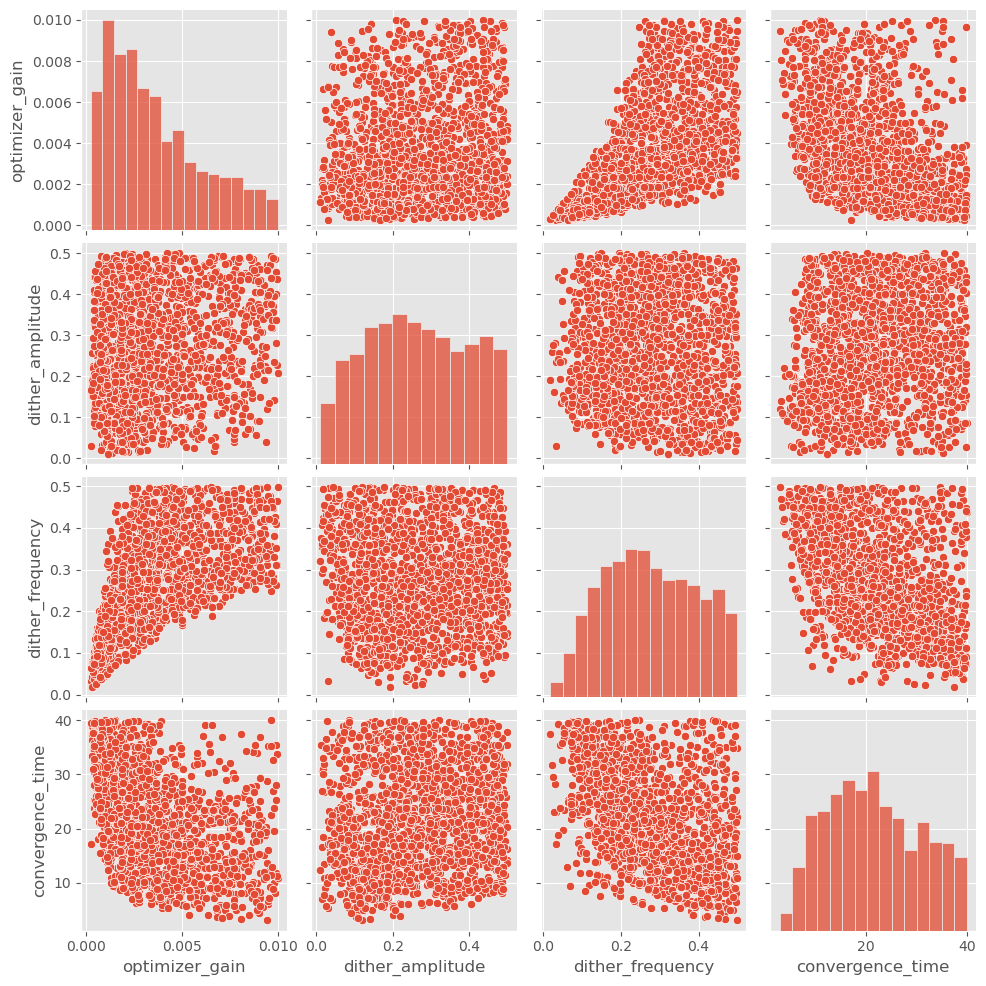

In [120]:
sns.pairplot(dfcut,
             vars = ['optimizer_gain','dither_amplitude','dither_frequency', 'convergence_time'])
plt.show()

# Gain and frequency have a direct relationship which makes sense as they both have inverse relationships with convergence time
# The relationships between amplitude and other variables are not very clear

<Axes: >

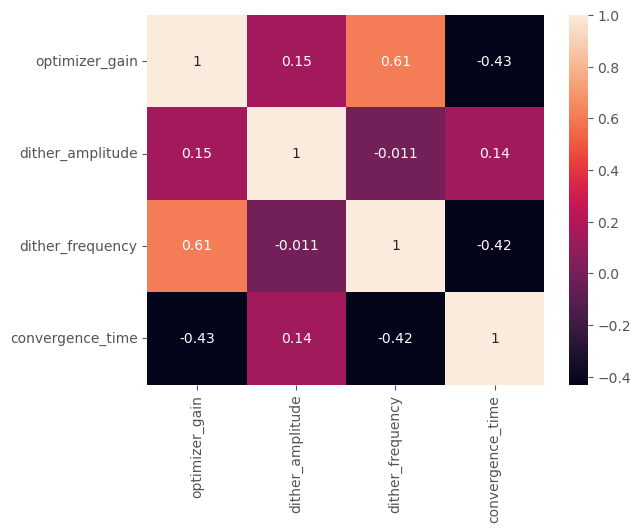

In [121]:
sns.heatmap(dfcut.drop(columns = 'y').corr(), annot = True)

# The relations are expected

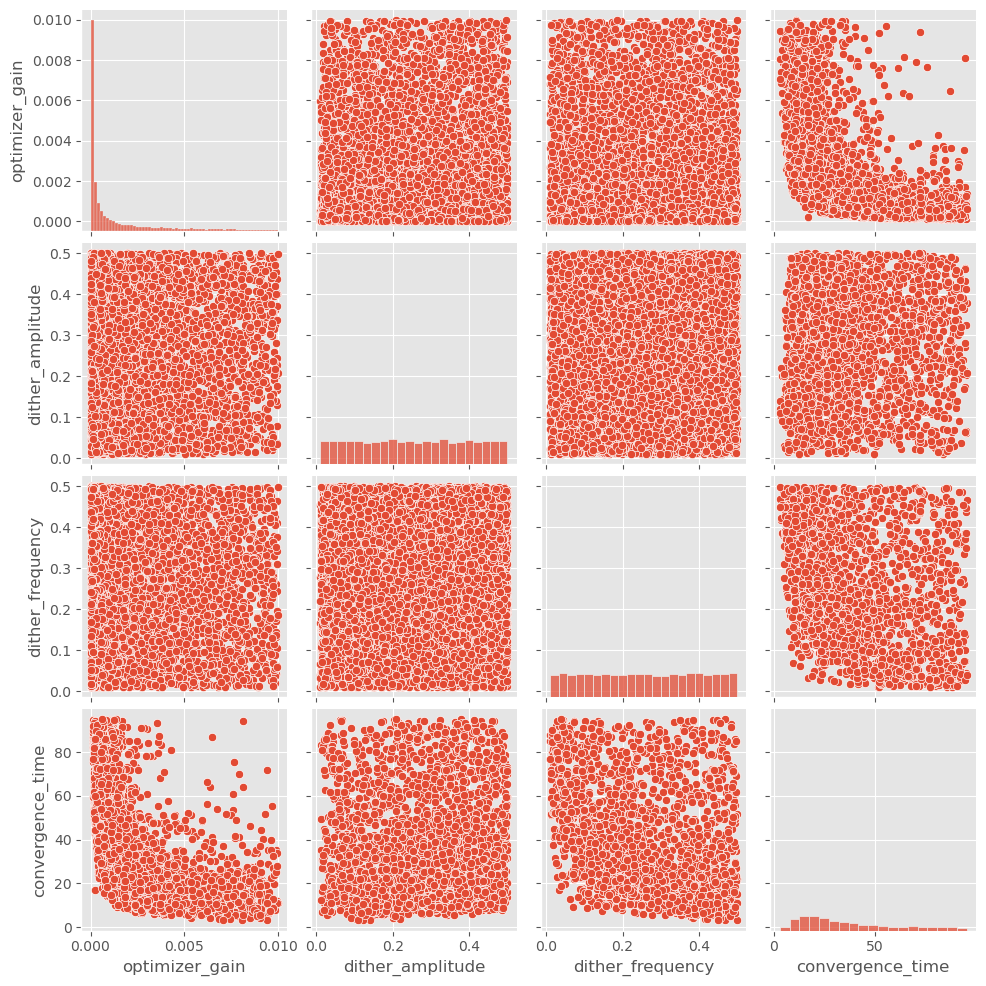

In [122]:
sns.pairplot(df,
             vars = ['optimizer_gain','dither_amplitude','dither_frequency', 'convergence_time'])
plt.show()

# We cannot see very clearly the relationship between gain and frequency anymore

<Axes: >

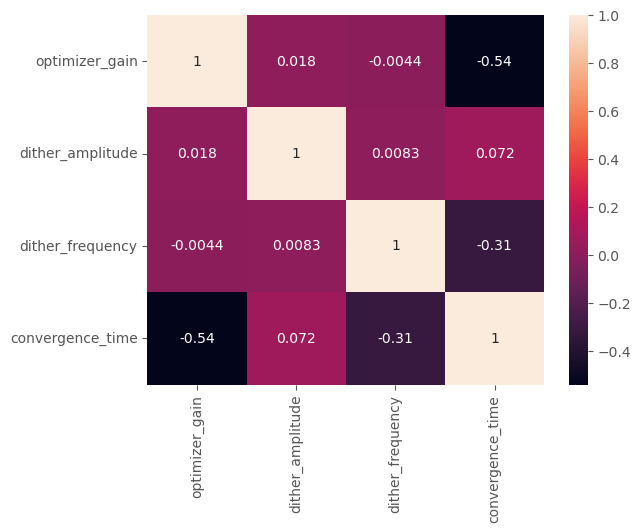

In [123]:
sns.heatmap(df.drop(columns = 'y').corr(), annot = True)

# The relationship between gain and convergence time is even stronger
# The relationships between frequency and gain/convergence time significantly decreases


# Modelling: Classification

In [124]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


In [125]:
# Create sets 1 for model 1

X11 = df.drop(columns=['convergence_time', 'y'])
y11 = df['y']

# Get 60% of the dataset as the training set. Put the remaining 40% in temporary variables: x_ and y_.
X_train11, X_, y_train11, y_ = train_test_split(X11, y11, test_size=0.40, random_state=1)

# Split the 40% subset above into two: one half for cross validation and the other for the test set
X_cv11, X_test11, y_cv11, y_test11 = train_test_split(X_, y_, test_size=0.50, random_state=1)

# Delete temporary variables
del X_, y_

In [126]:
# Create model 1 for set 1
model11 = Sequential(
    [
        Dense(32, activation='relu', name="L1"),
        Dense(16, activation='relu', name="L2"),
        Dense(1, activation = 'linear', name = "L3")  
    ]
)

Epoch 1/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5723 - val_loss: 0.5793
Epoch 2/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5645 - val_loss: 0.5686
Epoch 3/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5625 - val_loss: 0.5624
Epoch 4/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5575 - val_loss: 0.5501
Epoch 5/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5378 - val_loss: 0.5112
Epoch 6/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4916 - val_loss: 0.4414
Epoch 7/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4345 - val_loss: 0.4120
Epoch 8/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3920 - val_loss: 0.3760
Epoch 9/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3632 - val_loss: 0.3757
Epoch 10/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3587 - val_loss: 0.3464
Epoch 11/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3653 - val_loss: 0.3679
Epoch 12/200
188/188 ━━━━━━━━━━━━━━━━━━━━

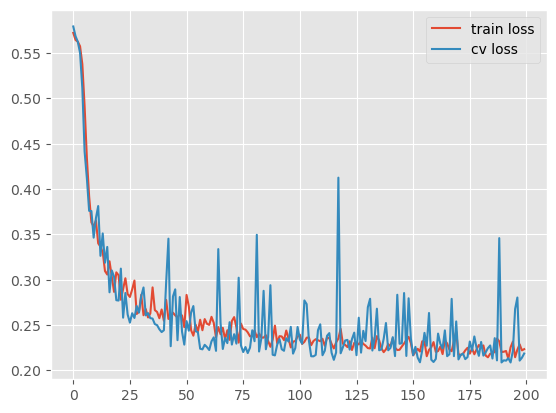

In [127]:
# Train model 1 with sets 1

model11.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)
history11 = model11.fit(X_train11, 
                     y_train11, 
                     epochs=200, 
                     validation_data=(X_cv11, y_cv11))
plt.plot(history11.history['loss'], label='train loss')
plt.plot(history11.history['val_loss'], label='cv loss')
plt.legend()
plt.show()

In [128]:
logits11 = model11.predict(X_cv11)
probs11 = tf.sigmoid(logits11).numpy() # convert logit to probability
y_pred11 = (probs11 > 0.5).astype(int).flatten() # threshold at 0.5, flatten to 1D
accuracy11 = accuracy_score(y_cv11, y_pred11)
print(f"CV accuracy: {accuracy:.3f}")

# 91% accuracy. Nice!

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step
CV accuracy: 0.910


In [129]:
print(confusion_matrix(y_cv11, y_pred11))
print(classification_report(y_cv11, y_pred11))

# The precision for "1" is significantly lower than "0", only 0.78 compared to 0.96

[[1388  103]
 [  93  416]]
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      1491
           1       0.80      0.82      0.81       509

    accuracy                           0.90      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.90      0.90      0.90      2000



In [130]:
train_logits11 = model11.predict(X_train11)
train_probs11 = tf.sigmoid(train_logits11).numpy()
train_pred11 = (train_probs11 > 0.5).astype(int).flatten()
train_acc11 = accuracy_score(y_train11, train_pred11)
print(f"Train accuracy: {train_acc11:.3f}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 655us/step
Train accuracy: 0.902


In [131]:
# Optimizer gain is probably too small
df['log10gain'] = np.log10(df['optimizer_gain'])

In [132]:
# Create sets 2 for model 1

X12 = df.drop(columns=['convergence_time', 'y', 'convergence_time'])
y12 = df['y']

# Get 60% of the dataset as the training set. Put the remaining 40% in temporary variables: x_ and y_.
X_train12, X_, y_train12, y_ = train_test_split(X12, y12, test_size=0.40, random_state=1)

# Split the 40% subset above into two: one half for cross validation and the other for the test set
X_cv12, X_test12, y_cv12, y_test12 = train_test_split(X_, y_, test_size=0.50, random_state=1)

# Delete temporary variables
del X_, y_

In [133]:
# Create model 1 for set 2
model12 = Sequential(
    [
        Dense(32, activation='relu', name="L1"),
        Dense(16, activation='relu', name="L2"),
        Dense(1, activation = 'linear', name = "L3")  
    ]
)

Epoch 1/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4639 - val_loss: 0.4070
Epoch 2/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3744 - val_loss: 0.3349
Epoch 3/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3293 - val_loss: 0.3105
Epoch 4/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2792 - val_loss: 0.2665
Epoch 5/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2669 - val_loss: 0.2497
Epoch 6/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2660 - val_loss: 0.2504
Epoch 7/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2582 - val_loss: 0.2436
Epoch 8/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2534 - val_loss: 0.2404
Epoch 9/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2502 - val_loss: 0.2467
Epoch 10/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2500 - val_loss: 0.2358
Epoch 11/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2459 - val_loss: 0.2614
Epoch 12/200
188/188 ━━━━━━━━━━━━━━━━━━━━

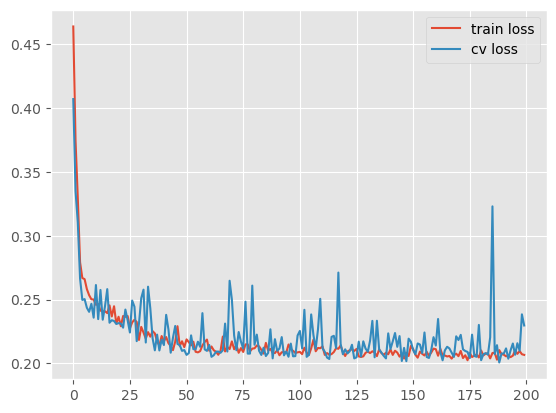

In [134]:
# Train model 1 with sets 2

model12.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)
history12 = model12.fit(X_train12, 
                     y_train12, 
                     epochs=200, 
                     validation_data=(X_cv12, y_cv12))
plt.plot(history12.history['loss'], label='train loss')
plt.plot(history12.history['val_loss'], label='cv loss')
plt.legend()
plt.show()

In [135]:
logits12 = model12.predict(X_cv12)
probs12 = tf.sigmoid(logits12).numpy() # convert logit to probability
y_pred12 = (probs12 > 0.5).astype(int).flatten() # threshold at 0.5, flatten to 1D
accuracy12 = accuracy_score(y_cv12, y_pred12)
print(f"CV accuracy: {accuracy:.3f}")



63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
CV accuracy: 0.910


In [136]:
print(confusion_matrix(y_cv12, y_pred12))
print(classification_report(y_cv12, y_pred12))

[[1333  158]
 [  70  439]]
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      1491
           1       0.74      0.86      0.79       509

    accuracy                           0.89      2000
   macro avg       0.84      0.88      0.86      2000
weighted avg       0.90      0.89      0.89      2000



In [137]:
train_logits12 = model12.predict(X_train12)
train_probs12 = tf.sigmoid(train_logits12).numpy()
train_pred12 = (train_probs2 > 0.5).astype(int).flatten()
train_acc12 = accuracy_score(y_train12, train_pred12)
print(f"Train accuracy: {train_acc12:.3f}")

# So optimizer gain being too small is probably not the case. 

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 607us/step
Train accuracy: 0.910


91% is nice but since this is a simple model, I expect it to have 95+%. 
Since Jcv and Jtrain are approximately the same, the model is very likely underfitting.
Based on the difference in precision and recall, I assume that the model is drawing the borderline cutting into the area of "0", which furthermore makes it likely to be underfitting. 